In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/Mobile_Reviews_GenData.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (4200, 25)


,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,review_length,word_count,helpful_votes,source
0,GENV2_04161,Aarav Mehta,49,Samsung,Galaxy S25 Ultra,799.14,1011.56,GBP,0.79,5,...,False,5,5,5,4,5,167,27,36,Synthetic-V2
1,GENV2_02118,Meera Joshi,53,Google,Pixel 10,714.86,714.86,USD,1.00,4,...,True,4,4,4,5,3,238,42,34,Synthetic-V2
2,GENV2_03543,Rohan Shah,50,Realme,Realme GT 7 Pro,390.09,390.09,USD,1.00,4,...,True,4,5,4,3,5,346,62,39,Synthetic-V2
3,GENV2_00201,Aarav Mehta,41,Apple,iPhone 16e,694.36,694.36,USD,1.00,2,...,False,3,2,2,3,3,273,46,54,Synthetic-V2
4,GENV2_03173,Aditya Jain,54,OPPO,Find X8 Pro,606.43,606.43,USD,1.00,5,...,True,5,4,5,4,3,325,54,55,Synthetic-V2


In [3]:
# Inspect Sample Reviews

pd.set_option("display.max_colwidth", 300)

sample_reviews = df[
    [
        "brand",
        "model",
        "rating",
        "sentiment",
        "review_text"
    ]
].sample(25, random_state=42)

sample_reviews

,brand,model,rating,sentiment,review_text
1743,Google,Pixel 9a,2,Negative,"My routine includes calls, photos, and some gaming. colors are not always consistent. feels familiar rather than distinctive. The compromises are difficult to overlook. I use it mostly during a normal workday."
2196,Apple,iPhone 17 Pro,5,Positive,the design has grown on me. night shots are cleaner than I expected. I mostly use it for work and messaging.
1728,Google,Pixel 10 Pro,5,Positive,I mostly use it for work and messaging. colors are pleasing without looking excessive. the camera handles portraits with good separation.
3337,Google,Pixel 10,3,Negative,"touch response has been dependable. I mostly use it for work and messaging. That said, night shots are cleaner than I expected. overnight loss is higher than I expected."
298,Apple,iPhone 17 Pro Max,4,Positive,night shots are cleaner than I expected. usually leaves plenty of charge by bedtime. The strengths make it easy for me to recommend. the panel looks bright in most situations. I have been using it as my main phone.
1837,Nothing,Nothing Phone 3,5,Positive,"My routine includes calls, photos, and some gaming. I have very few regrets about choosing it. I rarely think about the battery during the day. Still, longer gaming sessions can introduce stutter. it is comfortable to carry and use."
4016,OnePlus,OnePlus 13T,4,Neutral,"photos have a pleasing amount of detail. touch response has been dependable. it is comfortable enough to use. One catch is that, it needs a top-up before the day is over."
351,Apple,iPhone 16e,2,Negative,"Still, daylight shots come out crisp and detailed. some parts of the finish seem easy to mark. I spend a fair amount of time on maps, media, and social apps. I am already considering a different phone next time. is adequate for most daily tasks. I use it mostly during a normal workday."
3315,Realme,Realme GT 7 Pro,4,Positive,scrolling feels fluid on the high refresh rate. battery performance has been about what I expected. the design has grown on me.
2458,Apple,iPhone 17 Pro Max,5,Positive,"touch response has been dependable. charging has been quick enough for my routine. autofocus is okay for everyday subjects. Still, some parts of the finish seem easy to mark."


In [4]:
# Text Cleaning

def clean_text(text):
    text = str(text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Convert to lowercase
    text = text.lower()

    # Keep letters, numbers, spaces and useful punctuation
    text = re.sub(r"[^a-z0-9\s.,!?']", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_review"] = df["review_text"].apply(clean_text)

print("Text cleaning completed!")

df[
    ["review_text", "clean_review"]
].head(10)

Text cleaning completed!


,review_text,clean_review
0,usually leaves plenty of charge by bedtime. apps move along without much waiting. the panel looks bright in most situations. night shots are usable with some patience.,usually leaves plenty of charge by bedtime. apps move along without much waiting. the panel looks bright in most situations. night shots are usable with some patience.
1,"is adequate for most daily tasks. Still, I rarely think about the battery during the day. I could recommend it, but only with some reservations. the phone stays responsive under a busy workload. The software has been stable for me so far.","is adequate for most daily tasks. still, i rarely think about the battery during the day. i could recommend it, but only with some reservations. the phone stays responsive under a busy workload. the software has been stable for me so far."
2,"At the same time, the buttons do not feel as refined as I expected. I would choose this one again over the alternatives I considered. is adequate for most daily tasks. I spend a fair amount of time on maps, media, and social apps. photos have a pleasing amount of detail. games stay smooth during...","at the same time, the buttons do not feel as refined as i expected. i would choose this one again over the alternatives i considered. is adequate for most daily tasks. i spend a fair amount of time on maps, media, and social apps. photos have a pleasing amount of detail. games stay smooth during..."
3,longer gaming sessions can introduce stutter. the screen feels fairly typical for this class. the build is reasonable for the price. I would hesitate to recommend it in this price range. portraits can have uneven edge separation. The software has been stable for me so far.,longer gaming sessions can introduce stutter. the screen feels fairly typical for this class. the build is reasonable for the price. i would hesitate to recommend it in this price range. portraits can have uneven edge separation. the software has been stable for me so far.
4,"switching between apps feels effortless. I mostly use it for work and messaging. The strengths make it easy for me to recommend. daylight shots come out crisp and detailed. charging has been quick enough for my routine. One catch is that, touch response has occasionally felt delayed. the finish ...","switching between apps feels effortless. i mostly use it for work and messaging. the strengths make it easy for me to recommend. daylight shots come out crisp and detailed. charging has been quick enough for my routine. one catch is that, touch response has occasionally felt delayed. the finish ..."
5,night shots are cleaner than I expected. The strengths make it easy for me to recommend. holds up really well through a long day. the controls feel thoughtfully placed. I mostly use it for work and messaging.,night shots are cleaner than i expected. the strengths make it easy for me to recommend. holds up really well through a long day. the controls feel thoughtfully placed. i mostly use it for work and messaging.
6,autofocus is okay for everyday subjects. text stays sharp and easy to read. performance has been consistently strong. gets through a normal day for me. Most of my use is fairly ordinary rather than demanding. I have been using it as my main phone.,autofocus is okay for everyday subjects. text stays sharp and easy to read. performance has been consistently strong. gets through a normal day for me. most of my use is fairly ordinary rather than demanding. i have been using it as my main phone.
7,I mostly use it for work and messaging. works well enough for routine photos. it is comfortable to carry and use. the screen feels fairly typical for this class.,i mostly use it for work and messaging. works well enough for routine photos. it is comfortable to carry and use. the screen feels fairly typical for this class.
8,it is comfortable to carry and use. touch response has been dependable. I rarely think about the battery during the day. I bought it after compa

In [5]:
# Review Length Analysis

df["clean_word_count"] = (
    df["clean_review"]
    .str.split()
    .str.len()
)

df["clean_char_count"] = (
    df["clean_review"]
    .str.len()
)

print("Word count statistics:")
print(df["clean_word_count"].describe())

print("\nCharacter count statistics:")
print(df["clean_char_count"].describe())

Word count statistics:
count    4200.000000
mean       37.548571
std        10.710173
min        10.000000
25%        30.000000
50%        37.000000
75%        45.000000
max        73.000000
Name: clean_word_count, dtype: float64

Character count statistics:
count    4200.000000
mean      218.207857
std        59.969389
min        62.000000
25%       178.000000
50%       218.000000
75%       260.000000
max       398.000000
Name: clean_char_count, dtype: float64


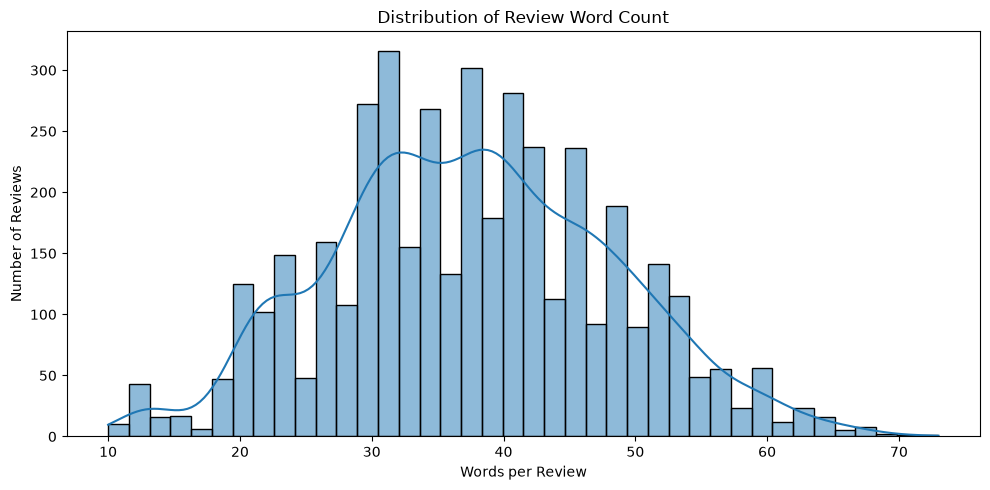

In [6]:
# Review word-count distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    df["clean_word_count"],
    bins=40,
    kde=True
)

plt.title("Distribution of Review Word Count")
plt.xlabel("Words per Review")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [7]:
# Sentiment vs Review Length

sentiment_length = (
    df.groupby("sentiment")["clean_word_count"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .round(2)
)

sentiment_length

,count,mean,median,std,min,max
sentiment,,,,,,
Negative,1386,36.66,36.0,10.61,10,67
Neutral,1050,39.29,39.0,10.74,11,73
Positive,1764,37.21,37.0,10.66,10,71


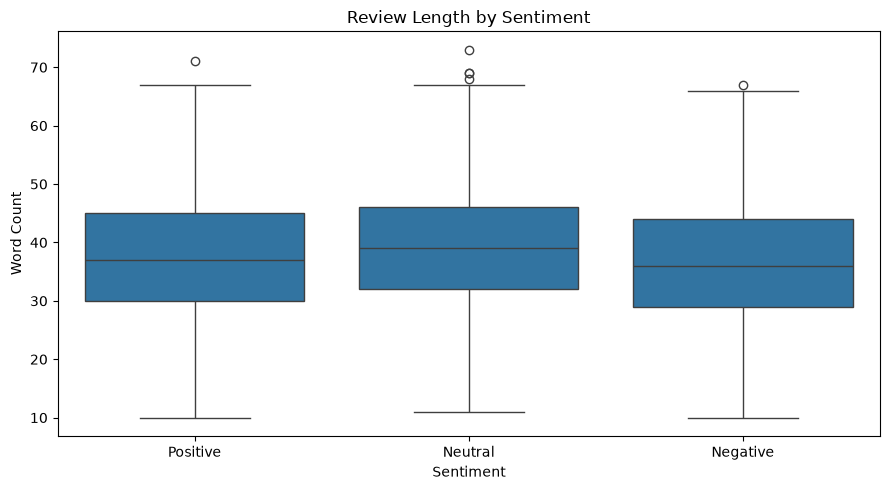

In [8]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="sentiment",
    y="clean_word_count",
    order=["Positive", "Neutral", "Negative"]
)

plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")

plt.tight_layout()
plt.show()

In [9]:
# Define Smartphone Aspects

aspects = {
    "battery": [
        "battery",
        "battery life",
        "charging",
        "charge",
        "drain",
        "screen-on time"
    ],

    "camera": [
        "camera",
        "photos",
        "photo",
        "portrait",
        "video",
        "night mode",
        "focus"
    ],

    "performance": [
        "performance",
        "gaming",
        "game",
        "processor",
        "multitasking",
        "apps",
        "slowdown",
        "stutter"
    ],

    "design": [
        "design",
        "build",
        "weight",
        "heavy",
        "light",
        "frame",
        "finish",
        "buttons"
    ],

    "display": [
        "display",
        "screen",
        "brightness",
        "colors",
        "refresh rate",
        "panel",
        "touch"
    ]
}

print("Aspects defined:")
for aspect in aspects:
    print("•", aspect)

Aspects defined:
• battery
• camera
• performance
• design
• display


In [10]:
# Aspect Mention Analysis

aspect_mention_counts = {}

for aspect, keywords in aspects.items():

    pattern = "|".join(
        re.escape(keyword)
        for keyword in keywords
    )

    mask = (
        df["clean_review"]
        .str.contains(
            pattern,
            case=False,
            regex=True,
            na=False
        )
    )

    aspect_mention_counts[aspect] = mask.sum()


aspect_mention_counts = pd.Series(
    aspect_mention_counts
).sort_values(ascending=False)

print("Number of reviews mentioning each aspect:\n")

aspect_mention_counts

Number of reviews mentioning each aspect:



performance    2894
camera         2072
display        2064
battery        1887
design         1700
dtype: int64

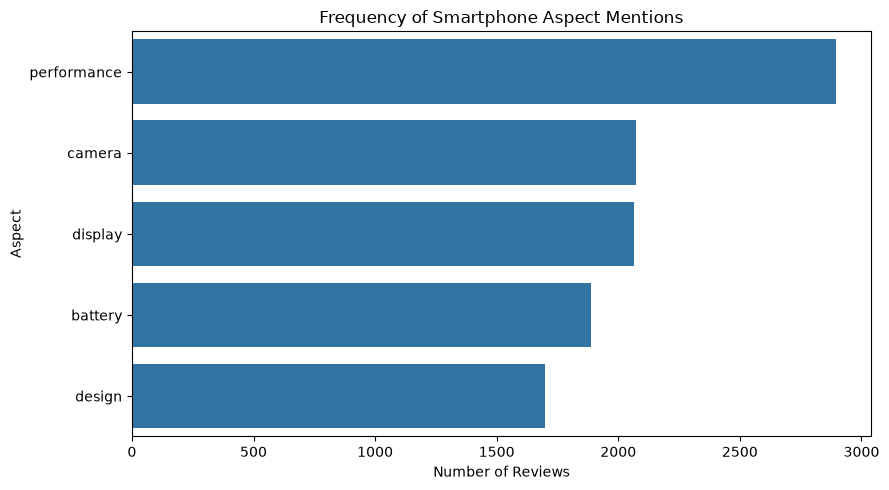

In [11]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=aspect_mention_counts.values,
    y=aspect_mention_counts.index
)

plt.title("Frequency of Smartphone Aspect Mentions")
plt.xlabel("Number of Reviews")
plt.ylabel("Aspect")

plt.tight_layout()
plt.show()

In [12]:
# Detect Aspects in Each Review

for aspect, keywords in aspects.items():

    pattern = "|".join(
        re.escape(keyword)
        for keyword in keywords
    )

    df[f"mentions_{aspect}"] = (
        df["clean_review"]
        .str.contains(
            pattern,
            case=False,
            regex=True,
            na=False
        )
    )


mention_columns = [
    "mentions_battery",
    "mentions_camera",
    "mentions_performance",
    "mentions_design",
    "mentions_display"
]

df["aspect_count"] = df[mention_columns].sum(axis=1)

print("Aspect count distribution:")
print(
    df["aspect_count"]
    .value_counts()
    .sort_index()
)

Aspect count distribution:
aspect_count
0      79
1     585
2    1440
3    1343
4     642
5     111
Name: count, dtype: int64


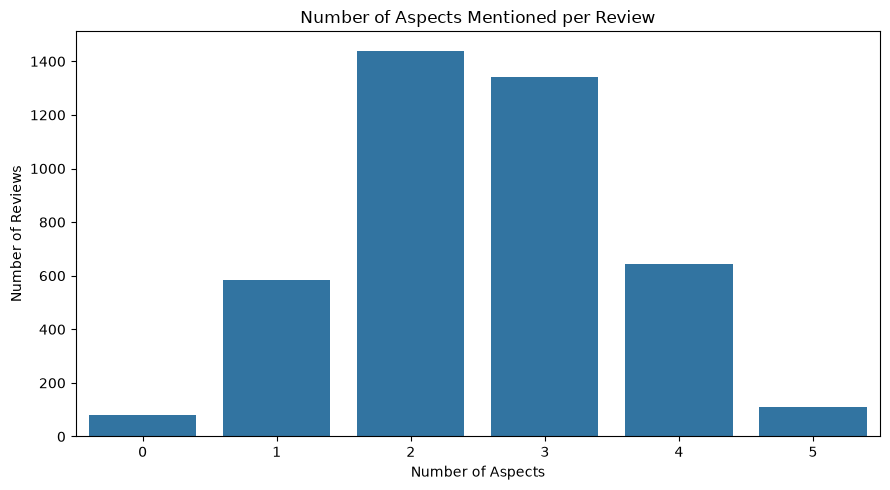

In [13]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="aspect_count"
)

plt.title("Number of Aspects Mentioned per Review")
plt.xlabel("Number of Aspects")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [14]:
# Inspect Multi-Aspect Reviews

multi_aspect_reviews = df[
    df["aspect_count"] >= 2
][
    [
        "brand",
        "model",
        "sentiment",
        "review_text",
        "aspect_count"
    ]
].sample(
    min(30, (df["aspect_count"] >= 2).sum()),
    random_state=42
)

multi_aspect_reviews

,brand,model,sentiment,review_text,aspect_count
3447,Apple,iPhone 16,Positive,"I mostly use it for work and messaging. battery performance has been about what I expected. apps move along without much waiting. text stays sharp and easy to read. nothing about the finish stands out much. One catch is that, night shots often need another try. The software has been stable for m...",3
325,Nothing,Phone 2a Plus,Negative,"the shape is not especially comfortable for me. One catch is that, I rarely think about the battery during the day. the camera output is less consistent than expected. touch response has been dependable.",3
950,Samsung,Galaxy S25 Ultra,Positive,"One catch is that, overnight loss is higher than I expected. I mostly use it for work and messaging. looks fine indoors and in shade. switching between apps feels effortless. daylight shots come out crisp and detailed.",2
1486,Motorola,Moto G Power 2025,Negative,"On the other hand, drain has been impressively low. switching between heavier apps is not always smooth. I would hesitate to recommend it in this price range. touch response has occasionally felt delayed. I bought it after comparing a few phones in the same range. the camera output is less consi...",5
3287,OnePlus,OnePlus 13,Positive,"the panel looks bright in most situations. My routine includes calls, photos, and some gaming. night shots are usable with some patience. The software has been stable for me so far.",3
2414,Xiaomi,Xiaomi 15 Ultra,Positive,"At the same time, the handset feels bulkier than expected. autofocus is okay for everyday subjects. usually leaves plenty of charge by bedtime.",2
3585,Xiaomi,Xiaomi 15,Negative,"One catch is that, I rarely think about the battery during the day. the design is functional and straightforward. I have more complaints than I expected to have. is adequate for most daily tasks. Most of my use is fairly ordinary rather than demanding.",2
1958,OnePlus,OnePlus 13T,Positive,"touch response has been dependable. games stay smooth during longer sessions. My routine includes calls, photos, and some gaming. I would recommend it to someone shopping in this range. charging has been quick enough for my routine.",4
567,Samsung,Galaxy S25 Ultra,Positive,"apps move along without much waiting. usually leaves plenty of charge by bedtime. On the other hand, some photos lose detail when the light drops. the design has grown on me. I mostly use it for work and messaging. I have been using it as my main phone.",4
1273,Samsung,Galaxy S26 Ultra,Positive,"text stays sharp and easy to read. I spend a fair amount of time on maps, media, and social apps. I am pleased with the purchase overall. the phone stays responsive under a busy workload. On the other hand, some parts of the finish seem easy to mark. gets through a normal day for me. I have been...",2


In [15]:
# Save Text-Processed Dataset

output_path = "../data/processed/mobile_reviews_text_processed.csv"

df.to_csv(
    output_path,
    index=False
)

print("✅ Text-processed dataset saved!")
print("📁", output_path)
print("📊 Shape:", df.shape)

✅ Text-processed dataset saved!
📁 ../data/processed/mobile_reviews_text_processed.csv
📊 Shape: (4200, 34)


In [16]:
aspect_mention_counts

performance    2894
camera         2072
display        2064
battery        1887
design         1700
dtype: int64

In [17]:
df["aspect_count"].value_counts().sort_index()

aspect_count
0      79
1     585
2    1440
3    1343
4     642
5     111
Name: count, dtype: int64

In [18]:
print("Final processed dataset shape:", df.shape)

print("\nSentiment distribution:")
print(
    df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nFirst review:")
print(df["review_text"].iloc[0])

Final processed dataset shape: (4200, 34)

Sentiment distribution:
sentiment
Positive    42.0
Negative    33.0
Neutral     25.0
Name: proportion, dtype: float64

First review:
usually leaves plenty of charge by bedtime. apps move along without much waiting. the panel looks bright in most situations. night shots are usable with some patience.
